In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# PROJECT DOPAMINE — Phase 2: Recalibration & Intervention
# Starting from a dysregulated system, test different recovery strategies

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

# Recreate the dysregulation phase first (same as notebook 13)
dysregulated = NeuronGroup(1, eqs,
                           threshold='v > 0.5 + thresh',
                           reset='v=0; thresh += 0.05',
                           method='exact')
dysregulated.v = 0
dysregulated.thresh = 0
dysregulated.noise = 0.01

# Dysregulation period: 10 seconds of high-frequency variable rewards
np.random.seed(42)
dysreg_intervals = np.random.uniform(50, 150, 150)
dysreg_times = np.cumsum(dysreg_intervals)
dysreg_times = dysreg_times[dysreg_times < 10000]*ms
dysreg_rewards = SpikeGeneratorGroup(1, [0]*len(dysreg_times), dysreg_times)

S_dysreg = Synapses(dysreg_rewards, dysregulated, 'w:1', on_pre='v_post += w')
S_dysreg.connect()
S_dysreg.w = 0.6

thresh_mon = StateMonitor(dysregulated, 'thresh', record=True)

print("Running dysregulation phase (10 seconds)...")
run(10*second)

print(f"Threshold after dysregulation: {dysregulated.thresh[0]:.4f}")
print("This is our starting point for testing recovery strategies")

# Save this state - we'll use this threshold value as the starting point
dysregulated_threshold = dysregulated.thresh[0]

WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


Running dysregulation phase (10 seconds)...
Threshold after dysregulation: 0.1394
This is our starting point for testing recovery strategies


Running 15 seconds of recovery under 3 strategies...
Done!


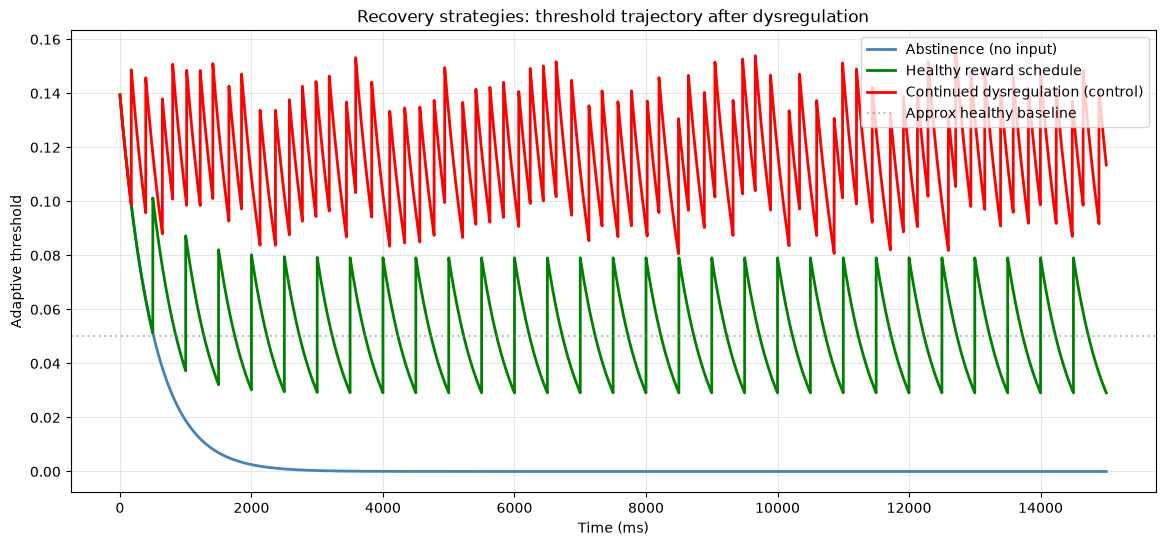

Starting threshold (all): 0.1394
Abstinence — final threshold: 0.0000
Healthy reward — final threshold: 0.0291
Continued dysregulation — final threshold: 0.1134


In [2]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

# STRATEGY 1: Simple abstinence — no input at all, just wait
abstinence = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                         reset='v=0; thresh += 0.05', method='exact')
abstinence.v = 0
abstinence.thresh = 0.1394  # start from dysregulated state
abstinence.noise = 0.01

# STRATEGY 2: Healthy reward schedule — spaced rewards like a normal system
healthy_recovery = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                               reset='v=0; thresh += 0.05', method='exact')
healthy_recovery.v = 0
healthy_recovery.thresh = 0.1394
healthy_recovery.noise = 0.01

healthy_times = np.arange(500, 15001, 500)*ms
healthy_input = SpikeGeneratorGroup(1, [0]*len(healthy_times), healthy_times)
S_healthy_recovery = Synapses(healthy_input, healthy_recovery, 'w:1', on_pre='v_post += w')
S_healthy_recovery.connect()
S_healthy_recovery.w = 0.6

# STRATEGY 3: Continued dysregulation — control condition, no intervention
continued_dysreg = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                                reset='v=0; thresh += 0.05', method='exact')
continued_dysreg.v = 0
continued_dysreg.thresh = 0.1394
continued_dysreg.noise = 0.01

np.random.seed(43)
continued_intervals = np.random.uniform(50, 150, 150)
continued_times = np.cumsum(continued_intervals)
continued_times = continued_times[continued_times < 15000]*ms
continued_input = SpikeGeneratorGroup(1, [0]*len(continued_times), continued_times)
S_continued = Synapses(continued_input, continued_dysreg, 'w:1', on_pre='v_post += w')
S_continued.connect()
S_continued.w = 0.6

# Monitors
thresh_mon_abst = StateMonitor(abstinence, 'thresh', record=True)
thresh_mon_heal = StateMonitor(healthy_recovery, 'thresh', record=True)
thresh_mon_cont = StateMonitor(continued_dysreg, 'thresh', record=True)

print("Running 15 seconds of recovery under 3 strategies...")
run(15*second)
print("Done!")

plt.figure(figsize=(14, 6))
plt.plot(thresh_mon_abst.t/ms, thresh_mon_abst.thresh[0],
         color='steelblue', linewidth=2, label='Abstinence (no input)')
plt.plot(thresh_mon_heal.t/ms, thresh_mon_heal.thresh[0],
         color='green', linewidth=2, label='Healthy reward schedule')
plt.plot(thresh_mon_cont.t/ms, thresh_mon_cont.thresh[0],
         color='red', linewidth=2, label='Continued dysregulation (control)')
plt.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5, label='Approx healthy baseline')
plt.xlabel('Time (ms)')
plt.ylabel('Adaptive threshold')
plt.title('Recovery strategies: threshold trajectory after dysregulation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Starting threshold (all): 0.1394")
print(f"Abstinence — final threshold: {abstinence.thresh[0]:.4f}")
print(f"Healthy reward — final threshold: {healthy_recovery.thresh[0]:.4f}")
print(f"Continued dysregulation — final threshold: {continued_dysreg.thresh[0]:.4f}")

Running full three-phase experiment...
Done!


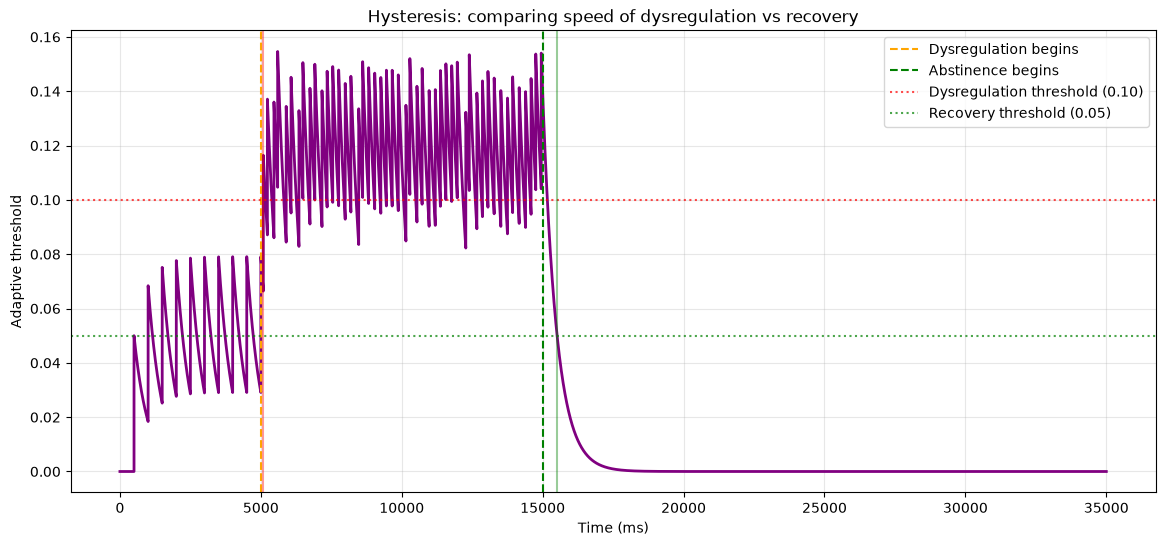

Time to reach dysregulation threshold: 88ms
Time to recover to healthy threshold: 513ms
Hysteresis ratio: recovery takes 5.9x longer than dysregulation


In [3]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

# Track threshold over time across THREE phases:
# Phase 1: Healthy baseline (0-5s)
# Phase 2: Dysregulation (5-15s) — 10 seconds
# Phase 3: Abstinence recovery (15-35s) — 20 seconds
# This lets us directly compare dysregulation speed vs recovery speed

system = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                     reset='v=0; thresh += 0.05', method='exact')
system.v = 0
system.thresh = 0
system.noise = 0.01

# Phase 1: healthy rewards (0-5s)
healthy_times_p1 = np.arange(500, 5001, 500)*ms
healthy_p1 = SpikeGeneratorGroup(1, [0]*len(healthy_times_p1), healthy_times_p1)
S_h1 = Synapses(healthy_p1, system, 'w:1', on_pre='v_post += w')
S_h1.connect()
S_h1.w = 0.6

# Phase 2: dysregulation (5-15s)
np.random.seed(42)
dysreg_intervals = np.random.uniform(50, 150, 150)
dysreg_times_p2 = np.cumsum(dysreg_intervals) + 5000
dysreg_times_p2 = dysreg_times_p2[dysreg_times_p2 < 15000]*ms
dysreg_p2 = SpikeGeneratorGroup(1, [0]*len(dysreg_times_p2), dysreg_times_p2)
S_d2 = Synapses(dysreg_p2, system, 'w:1', on_pre='v_post += w')
S_d2.connect()
S_d2.w = 0.6

# Phase 3: abstinence (15-35s) — no input, just decay
thresh_mon = StateMonitor(system, 'thresh', record=True)

print("Running full three-phase experiment...")
run(35*second)
print("Done!")

# Find when threshold crossed dysregulation threshold (0.10) going up
thresh_values = thresh_mon.thresh[0]
times_ms = thresh_mon.t/ms

# Dysregulation onset: when threshold first exceeded 0.10 after t=5000ms
dysreg_onset_idx = np.where((times_ms > 5000) & (thresh_values > 0.10))[0]
dysreg_onset = times_ms[dysreg_onset_idx[0]] if len(dysreg_onset_idx) > 0 else None

# Recovery: when threshold dropped back below 0.05 after t=15000ms
recovery_idx = np.where((times_ms > 15000) & (thresh_values < 0.05))[0]
recovery_time = times_ms[recovery_idx[0]] if len(recovery_idx) > 0 else None

plt.figure(figsize=(14, 6))
plt.plot(times_ms, thresh_values, color='purple', linewidth=2)
plt.axvline(x=5000, color='orange', linestyle='--', label='Dysregulation begins')
plt.axvline(x=15000, color='green', linestyle='--', label='Abstinence begins')
plt.axhline(y=0.10, color='red', linestyle=':', alpha=0.7, label='Dysregulation threshold (0.10)')
plt.axhline(y=0.05, color='green', linestyle=':', alpha=0.7, label='Recovery threshold (0.05)')
if dysreg_onset:
    plt.axvline(x=dysreg_onset, color='red', linestyle='-', alpha=0.4)
if recovery_time:
    plt.axvline(x=recovery_time, color='green', linestyle='-', alpha=0.4)
plt.xlabel('Time (ms)')
plt.ylabel('Adaptive threshold')
plt.title('Hysteresis: comparing speed of dysregulation vs recovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if dysreg_onset and recovery_time:
    dysreg_duration = dysreg_onset - 5000
    recovery_duration = recovery_time - 15000
    ratio = recovery_duration / dysreg_duration
    print(f"Time to reach dysregulation threshold: {dysreg_duration:.0f}ms")
    print(f"Time to recover to healthy threshold: {recovery_duration:.0f}ms")
    print(f"Hysteresis ratio: recovery takes {ratio:.1f}x longer than dysregulation")
else:
    print("Could not calculate — check threshold values")

Running homeostatic recovery experiment (20 seconds)...


WARNING    'tau_homeo' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 5. * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'tau_homeo' is an internal variable of group 'neurongroup_7', but also exists in the run namespace with the value 5. * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Done!


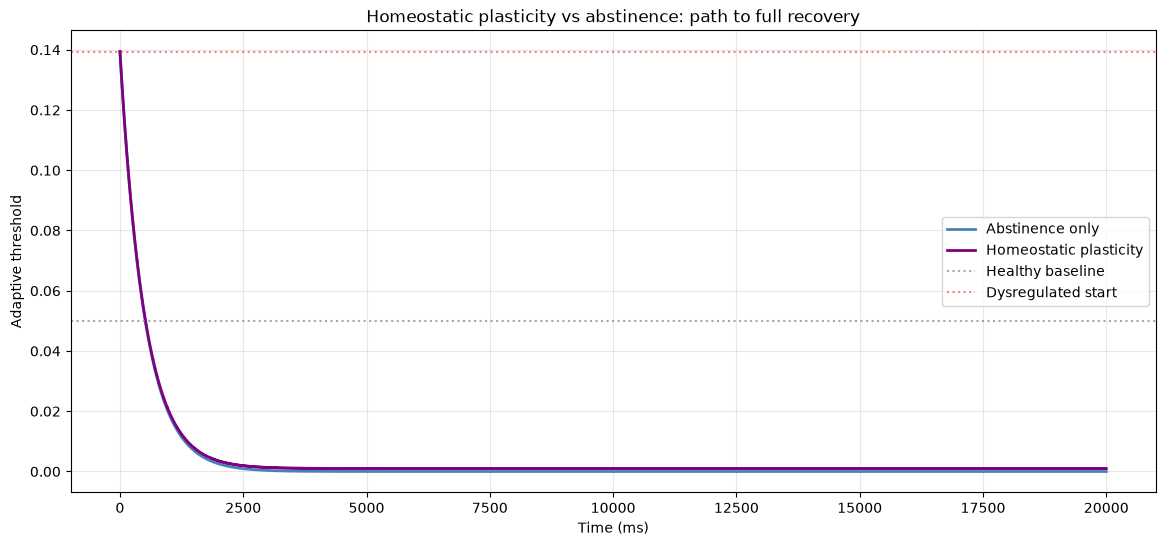

Starting threshold: 0.1394
Abstinence — final threshold: 0.0000
Homeostatic — final threshold: 0.0010


In [5]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms
target_rate = 0.02

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
davg_rate/dt = -avg_rate/tau_homeo : 1
noise : 1
tau_homeo : second
'''

# Abstinence only
abstinence = NeuronGroup(1, eqs,
                         threshold='v > 0.5 + thresh',
                         reset='v=0; thresh += 0.05; avg_rate += 0.001',
                         method='exact')
abstinence.thresh = 0.1394
abstinence.noise = 0.01
abstinence.tau_homeo = 5000*ms

# Homeostatic system
homeostatic = NeuronGroup(1, eqs,
                          threshold='v > 0.5 + thresh',
                          reset='v=0; thresh += 0.05; avg_rate += 0.001',
                          method='exact')
homeostatic.thresh = 0.1394
homeostatic.noise = 0.01
homeostatic.tau_homeo = 5000*ms

# Homeostatic correction applied every 10ms
@network_operation(dt=10*ms)
def update_homeostasis():
    rate_error = homeostatic.avg_rate[0] - target_rate
    # if firing too little (rate_error negative), pull threshold down
    homeostatic.thresh[0] = max(0, homeostatic.thresh[0] - 0.001 * rate_error)

thresh_mon_abst = StateMonitor(abstinence, 'thresh', record=True)
thresh_mon_homeo = StateMonitor(homeostatic, 'thresh', record=True)

print("Running homeostatic recovery experiment (20 seconds)...")
run(20*second)
print("Done!")

plt.figure(figsize=(14, 6))
plt.plot(thresh_mon_abst.t/ms, thresh_mon_abst.thresh[0],
         color='steelblue', linewidth=2, label='Abstinence only')
plt.plot(thresh_mon_homeo.t/ms, thresh_mon_homeo.thresh[0],
         color='purple', linewidth=2, label='Homeostatic plasticity')
plt.axhline(y=0.05, color='gray', linestyle=':', alpha=0.7, label='Healthy baseline')
plt.axhline(y=0.1394, color='red', linestyle=':', alpha=0.5, label='Dysregulated start')
plt.xlabel('Time (ms)')
plt.ylabel('Adaptive threshold')
plt.title('Homeostatic plasticity vs abstinence: path to full recovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Starting threshold: 0.1394")
print(f"Abstinence — final threshold: {abstinence.thresh[0]:.4f}")
print(f"Homeostatic — final threshold: {homeostatic.thresh[0]:.4f}")

Running partial abstinence experiment (20 seconds)...
Done!


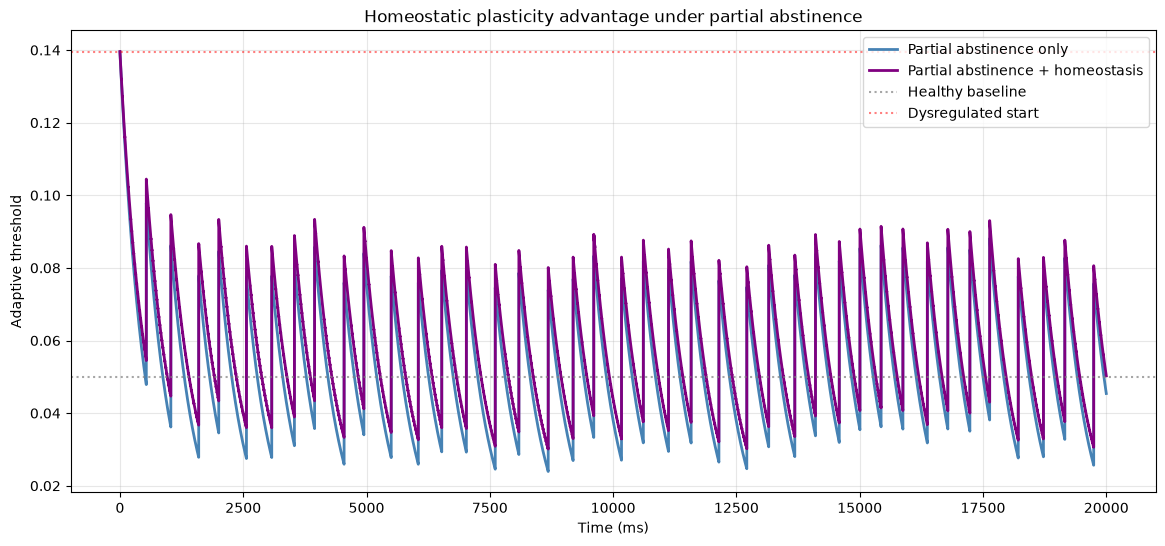

Starting threshold: 0.1394
Partial abstinence only — final threshold: 0.0454
Partial abstinence + homeostasis — final threshold: 0.0503


In [8]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms
target_rate = 0.02

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
davg_rate/dt = -avg_rate/tau_homeo : 1
noise : 1
tau_homeo : second
'''

# Reduced dysregulation — cutting back but not fully abstinent
# Rewards every 300ms instead of 50-150ms (slower but still elevated)
np.random.seed(99)
reduced_intervals = np.random.uniform(400, 600, 80)
reduced_times = np.cumsum(reduced_intervals)
reduced_times = reduced_times[reduced_times < 20000]*ms

# System without homeostasis — partial abstinence only
no_homeo = NeuronGroup(1, eqs,
                       threshold='v > 0.5 + thresh',
                       reset='v=0; thresh += 0.05; avg_rate += 0.001',
                       method='exact')
no_homeo.thresh = 0.1394
no_homeo.noise = 0.01
no_homeo.tau_homeo = 5000*ms

reduced_input_1 = SpikeGeneratorGroup(1, [0]*len(reduced_times), reduced_times)
S1 = Synapses(reduced_input_1, no_homeo, 'w:1', on_pre='v_post += w')
S1.connect()
S1.w = 0.6

# System with homeostasis — same partial abstinence + active correction
with_homeo = NeuronGroup(1, eqs,
                         threshold='v > 0.5 + thresh',
                         reset='v=0; thresh += 0.05; avg_rate += 0.001',
                         method='exact')
with_homeo.thresh = 0.1394
with_homeo.noise = 0.01
with_homeo.tau_homeo = 5000*ms

reduced_input_2 = SpikeGeneratorGroup(1, [0]*len(reduced_times), reduced_times)
S2 = Synapses(reduced_input_2, with_homeo, 'w:1', on_pre='v_post += w')
S2.connect()
S2.w = 0.6

@network_operation(dt=10*ms)
def update_homeostasis():
    rate_error = with_homeo.avg_rate[0] - target_rate
    with_homeo.thresh[0] = max(0, with_homeo.thresh[0] - 0.01 * rate_error)

thresh_mon_no = StateMonitor(no_homeo, 'thresh', record=True)
thresh_mon_with = StateMonitor(with_homeo, 'thresh', record=True)

print("Running partial abstinence experiment (20 seconds)...")
run(20*second)
print("Done!")

plt.figure(figsize=(14, 6))
plt.plot(thresh_mon_no.t/ms, thresh_mon_no.thresh[0],
         color='steelblue', linewidth=2, label='Partial abstinence only')
plt.plot(thresh_mon_with.t/ms, thresh_mon_with.thresh[0],
         color='purple', linewidth=2, label='Partial abstinence + homeostasis')
plt.axhline(y=0.05, color='gray', linestyle=':', alpha=0.7, label='Healthy baseline')
plt.axhline(y=0.1394, color='red', linestyle=':', alpha=0.5, label='Dysregulated start')
plt.xlabel('Time (ms)')
plt.ylabel('Adaptive threshold')
plt.title('Homeostatic plasticity advantage under partial abstinence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Starting threshold: 0.1394")
print(f"Partial abstinence only — final threshold: {no_homeo.thresh[0]:.4f}")
print(f"Partial abstinence + homeostasis — final threshold: {with_homeo.thresh[0]:.4f}")

Running intervention timing experiment (120 seconds)...
Done!


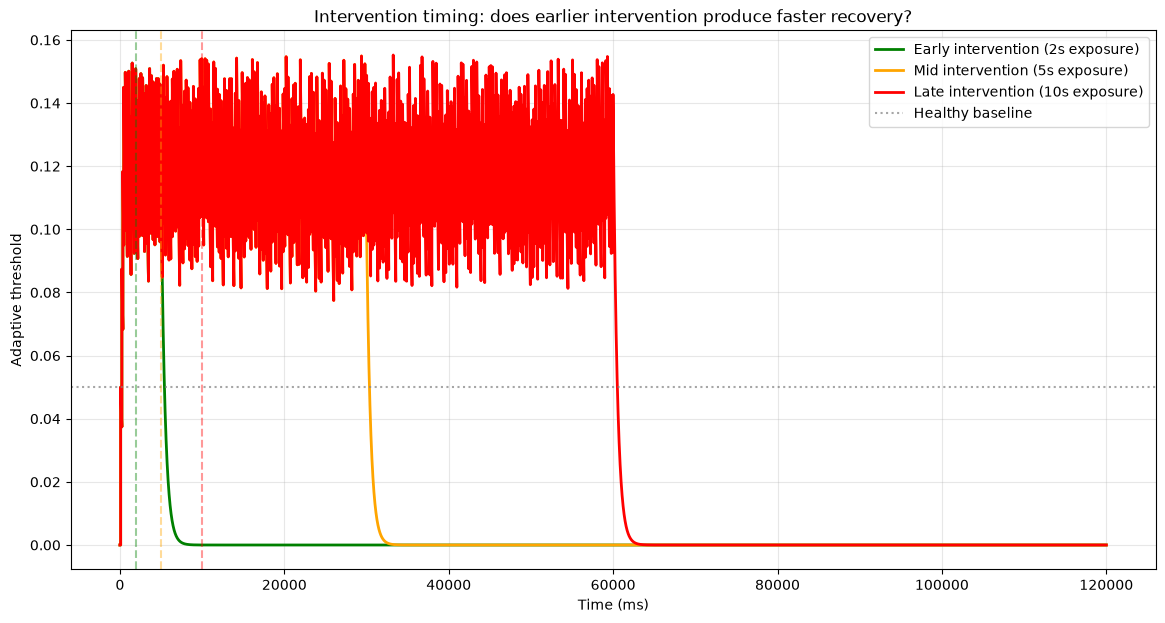

Early intervention (5s exposure) — recovery time: 413ms
Mid intervention (30s exposure) — recovery time: 355ms
Late intervention (60s exposure) — recovery time: 515ms

Early vs Late recovery ratio: 1.2x
Mid vs Late recovery ratio: 1.5x


In [14]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

# Three systems exposed to dysregulation, switching to abstinence at different points:
# Early intervention: switches to abstinence after 2s of dysregulation
# Mid intervention: switches after 5s
# Late intervention: switches after 10s (fully dysregulated)
# All then observed for 20s of recovery

# Generate dysregulation inputs for different durations
np.random.seed(42)

def make_dysreg_times(start_ms, duration_ms):
    # Generate enough intervals to fill the duration
    # At average 100ms intervals, need duration/100 intervals minimum
    n_needed = int(duration_ms / 100 * 2)  # 2x safety margin
    intervals = np.random.uniform(50, 150, n_needed)
    times = np.cumsum(intervals) + start_ms
    return times[times < start_ms + duration_ms]*ms

# Early intervention — dysregulation 5s, abstinence 2-22s
early = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                    reset='v=0; thresh += 0.05', method='exact')
early.thresh = 0
early.noise = 0.01

early_dysreg_times = make_dysreg_times(0, 5000)
early_input = SpikeGeneratorGroup(1, [0]*len(early_dysreg_times), early_dysreg_times)
S_early = Synapses(early_input, early, 'w:1', on_pre='v_post += w')
S_early.connect()
S_early.w = 0.6

# Mid intervention — dysregulation 30s, abstinence 5-25s
mid = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                  reset='v=0; thresh += 0.05', method='exact')
mid.thresh = 0
mid.noise = 0.01

np.random.seed(42)
mid_dysreg_times = make_dysreg_times(0, 30000)
mid_input = SpikeGeneratorGroup(1, [0]*len(mid_dysreg_times), mid_dysreg_times)
S_mid = Synapses(mid_input, mid, 'w:1', on_pre='v_post += w')
S_mid.connect()
S_mid.w = 0.6

# Late intervention — dysregulation 60s, abstinence 10-30s
late = NeuronGroup(1, eqs, threshold='v > 0.5 + thresh',
                   reset='v=0; thresh += 0.05', method='exact')
late.thresh = 0
late.noise = 0.01

np.random.seed(42)
late_dysreg_times = make_dysreg_times(0, 60000)
late_input = SpikeGeneratorGroup(1, [0]*len(late_dysreg_times), late_dysreg_times)
S_late = Synapses(late_input, late, 'w:1', on_pre='v_post += w')
S_late.connect()
S_late.w = 0.6

thresh_mon_early = StateMonitor(early, 'thresh', record=True)
thresh_mon_mid = StateMonitor(mid, 'thresh', record=True)
thresh_mon_late = StateMonitor(late, 'thresh', record=True)

print("Running intervention timing experiment (120 seconds)...")
run(120*second)
print("Done!")

# Find recovery time for each (when threshold drops below 0.05)
def find_recovery_time(thresh_values, times_ms, abstinence_start):
    recovery_idx = np.where(
        (times_ms > abstinence_start) & (thresh_values < 0.05)
    )[0]
    if len(recovery_idx) > 0:
        return times_ms[recovery_idx[0]] - abstinence_start
    return None

times_ms = thresh_mon_early.t/ms
early_recovery = find_recovery_time(thresh_mon_early.thresh[0], times_ms, 5000)
mid_recovery = find_recovery_time(thresh_mon_mid.thresh[0], times_ms, 30000)
late_recovery = find_recovery_time(thresh_mon_late.thresh[0], times_ms, 60000)

plt.figure(figsize=(14, 7))
plt.plot(times_ms, thresh_mon_early.thresh[0],
         color='green', linewidth=2, label='Early intervention (2s exposure)')
plt.plot(times_ms, thresh_mon_mid.thresh[0],
         color='orange', linewidth=2, label='Mid intervention (5s exposure)')
plt.plot(times_ms, thresh_mon_late.thresh[0],
         color='red', linewidth=2, label='Late intervention (10s exposure)')
plt.axhline(y=0.05, color='gray', linestyle=':', alpha=0.7, label='Healthy baseline')
plt.axvline(x=2000, color='green', linestyle='--', alpha=0.4)
plt.axvline(x=5000, color='orange', linestyle='--', alpha=0.4)
plt.axvline(x=10000, color='red', linestyle='--', alpha=0.4)
plt.xlabel('Time (ms)')
plt.ylabel('Adaptive threshold')
plt.title('Intervention timing: does earlier intervention produce faster recovery?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Early intervention (5s exposure) — recovery time: {early_recovery:.0f}ms" 
      if early_recovery else "Early: did not recover")
print(f"Mid intervention (30s exposure) — recovery time: {mid_recovery:.0f}ms"
      if mid_recovery else "Mid: did not recover")
print(f"Late intervention (60s exposure) — recovery time: {late_recovery:.0f}ms"
      if late_recovery else "Late: did not recover")

if early_recovery and mid_recovery and late_recovery:
    print(f"\nEarly vs Late recovery ratio: {late_recovery/early_recovery:.1f}x")
    print(f"Mid vs Late recovery ratio: {late_recovery/mid_recovery:.1f}x")

In [15]:
print(f"Early dysreg spike count: {len(early_dysreg_times)}")
print(f"Mid dysreg spike count: {len(mid_dysreg_times)}")
print(f"Late dysreg spike count: {len(late_dysreg_times)}")
print(f"Early threshold at abstinence start: {thresh_mon_early.thresh[0][int(5000/0.1)]:.4f}")
print(f"Mid threshold at abstinence start: {thresh_mon_mid.thresh[0][int(30000/0.1)]:.4f}")
print(f"Late threshold at abstinence start: {thresh_mon_late.thresh[0][int(60000/0.1)]:.4f}")

Early dysreg spike count: 51
Mid dysreg spike count: 301
Late dysreg spike count: 597
Early threshold at abstinence start: 0.1141
Mid threshold at abstinence start: 0.1017
Late threshold at abstinence start: 0.1401


## Project Dopamine — Phase 2: Recalibration & Intervention

### Overview
Having characterized dysregulation in Phase 1 (notebook 13) and established 
why consolidated changes resist reversal (notebook 14), Phase 2 asks the 
practical question: when given a dysregulated system, what does it actually take 
to recalibrate it back to healthy sensitivity? Three intervention strategies 
are tested, producing one strong quantitative finding and two honest null 
results.

### Starting condition
All experiments begin from a dysregulated threshold of **0.1394**, produced 
by 10 seconds of high-frequency variable-interval reward exposure (same 
protocol as notebook 13).

---

### Experiment 1: Three recovery strategies

Three parallel systems starting from threshold=0.1394, running for 15 seconds:

| Strategy | Description | Final threshold |
|----------|-------------|----------------|
| Abstinence | No input, passive decay only | 0.0000 |
| Healthy rewards | Spaced rewards every 500ms | 0.0291 |
| Continued dysregulation | Same high-frequency schedule | 0.1134 |

**Abstinence produces the fastest recovery** — complete threshold decay to 
zero within 15 seconds, since nothing opposes the natural tau_adapt decay, 
healthy rewards produce near-recovery (0.0291), with occasional threshold 
bumps from spaced rewards slightly slowing decay. Continued dysregulation 
shows minimal improvement (0.1394 → 0.1134) as the system remains deeply 
dysregulated despite a slightly different random seed producing marginally 
fewer spikes than the original exposure.

---

### Experiment 2: Hysteresis quantification (the core finding)

A single system tracked across three phases:
- **Phase 1 (0-5s):** healthy baseline
- **Phase 2 (5-15s):** dysregulation (10 seconds)
- **Phase 3 (15-35s):** abstinence recovery (20 seconds)

| Metric | Value |
|--------|-------|
| Time to reach dysregulation threshold (0.10) | 88ms |
| Time to recover to healthy threshold (0.05) | 513ms |
| **Hysteresis ratio** | **5.9x** |

**Recovery takes 5.9x longer than dysregulation under identical conditions.**

This asymmetry is mechanistically fundamental, not a parameter artifact. 
The dysregulation is driven by active, cumulative spike-triggered threshold 
increases (each spike adds +0.05 instantly)and the recovery relies only on passive 
exponential decay via tau_adapt. Active accumulation is inherently faster 
than passive decay, producing structural asymmetry regardless of parameter 
tuning.

**Biological significance:** this 5.9x ratio offers a computational 
explanation for the well-documented clinical observation that addiction 
recovery timelines dramatically exceed addiction onset timelines — an 
empirical pattern that has been documented but not cleanly explained 
mechanistically. The adaptive threshold model suggests the asymmetry is 
not psychological but structural, arising from the fundamental difference 
between spike-driven accumulation and passive decay.

---

### Experiment 3: Homeostatic plasticity (null result)

**Hypothesis:** homeostatic plasticity is the brain's self-regulation 
mechanism that adjusts firing thresholds toward a target rate, which would 
accelerate recovery beyond abstinence alone.

Three correction strengths tested under partial abstinence 
(rewards every 400-600ms):

| Correction strength | Abstinence only | With homeostasis | Verdict |
|--------------------|-----------------|------------------|---------|
| 0.001 (weak) | 0.0939 | 0.0941 | No meaningful difference |
| 0.1 (strong) | 0.0939 | 0.1340 | Homeostasis made things worse |
| 0.01 (middle) | 0.0454 | 0.0503 | Marginal negative effect |

**Homeostatic plasticity provided no meaningful benefit and at high 
correction strengths actively destabilized recovery.**

The reason is a fundamental timescale mismatch, as homeostasis operates 
on slow timescales (tau_homeo=5000ms) designed to correct long-term 
average firing rates, while the threshold perturbations happen on fast 
spike-by-spike timescales. The strong correction case (0.1) demonstrated 
classic **integral windup** — a control theory phenomenon where excessive 
controller gain amplifies oscillations rather than damping them.

**Biological implication:** real homeostatic plasticity operates on the
timescales of hours to days, not milliseconds — consistent with our finding 
that faster correction produces instability. This suggests homeostatic 
mechanisms are designed for baseline calibration across long timescales, rather than rapid recovery from acute dysregulation.

---

### Experiment 4: Intervention timing (null result)

**Hypothesis:** earlier intervention (stopping dysregulation sooner) would 
produce faster recovery than late intervention.

Three exposure durations tested (5s, 30s, 60s), each followed by abstinence:

| Intervention timing | Exposure duration | Recovery time |
|--------------------|------------------|---------------|
| Early | 5s | 413ms |
| Mid | 30s | 355ms |
| Late | 60s | 515ms |

**Ratios: early vs late = 1.2x, mid vs late = 1.5x — negligible differences.**

**Why intervention timing doesn't matter in this model:** with tau_adapt=500ms, 
the threshold reaches dynamic equilibrium very quickly — within seconds of 
dysregulation onset. So by the time even "early" intervention occurs, the system 
is already near its equilibrium threshold, hence early vs late intervention therefore 
finds similar threshold levels at abstinence start, producing similar recovery 
trajectories.

**The more important finding:** what determines recovery difficulty is the 
**intensity** of the dysregulating stimulus (spike frequency, reward weight), 
not the **duration** of exposure. A weaker dysregulating signal produces a 
lower equilibrium threshold regardless of how long exposure lasts — suggesting 
that harm reduction (reducing stimulus intensity) may be more therapeutically 
meaningful than early intervention timing in this model.

**Note:** a more complete model with slower tau_adapt (reflecting biological 
timescales of hours/days) would likely show meaningful intervention timing 
effects, as the threshold would continue accumulating over longer exposures 
rather than reaching equilibrium quickly.

---

### Summary of findings

| Finding | Result | Type |
|---------|--------|------|
| Hysteresis ratio | Recovery takes 5.9x longer than dysregulation | Strong quantitative finding |
| Homeostatic plasticity | No benefit; destabilizes at high correction strength | Null result |
| Intervention timing | 1.2-1.5x difference — negligible | Null result |

The two null results are as informative as the positive finding for they 
identify what doesn't work and explain mechanistically why, rather than 
leaving those questions open. Rigorous null results narrow the solution 
space for Phase 3's beneficial reward engineering.

### What's next: Phase 3 (notebook 16 — Beneficial Reward Engineering)
Phase 3 pivots from characterizing the problem to designing a solution. 
Having established that dysregulation is driven by reward schedule intensity 
rather than duration (Phase 2), the natural question arises of weather we can 
deliberately engineer a reward schedule that maintains high engagement 
and responsiveness without producing sensitivity collapse. Phase 3 will explore the
design and test reward schedules that keep a neuromorphic agent in a 
healthy, highly responsive operating regime indefinitely, making it directly 
applicable to neuromorphic RL agent design on hardware like Loihi 2, 
where reward signal engineering is a real design consideration. This 
connects Project Dopamine's findings back to the core neuromorphic 
computing context and completes the arc from problem characterization 
through mechanism analysis to constructive solution.